# Recon TAN for bulk

## Make correlation matrix npz

In [12]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import numpy as np
from deeptan.graph.recon import compute_feature_correlations

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
path_pkl = "/mnt/hdd2/homext/wuch/xn2p/run/predict/deeptan/bulk_exp_meth/preds+seed_42+multitask+tst.pkl"

In [4]:
output_cor_mat = os.path.join(os.path.dirname(path_pkl), os.path.basename(path_pkl) + "." + "correlation_matrix.npz")
if not os.path.exists(output_cor_mat):
    compute_feature_correlations(output_cor_mat, path_pkl)
else:
    print(f"Correlation matrix already exists at {output_cor_mat}")

Processing samples: 100%|██████████| 150/150 [00:00<00:00, 300.54it/s]



🔥Correlation matrix shape: (6361, 6361)


In [13]:
with open(path_pkl, "rb") as f:
    data_pkl = pickle.load(f)

In [14]:
print(data_pkl.keys())

dict_keys(['g_embedding', 'node_recon', 'node_recon_all', 'labels', 'dict_node_names', 'output_g_label_dim', 'label_names'])


In [22]:
feature_names = list(data_pkl["dict_node_names"].keys())
print(feature_names)

['AT1G01130', 'AT1G01200', 'AT1G01380', 'AT1G01570', 'AT1G01715', 'AT1G01810', 'AT1G01900', 'AT1G02050', 'AT1G02065', 'AT1G02205', 'AT1G02390', 'AT1G02470', 'AT1G02490', 'AT1G02610', 'AT1G02700', 'AT1G02705', 'AT1G02740', 'AT1G02800', 'AT1G02820', 'AT1G02860', 'AT1G02950', 'AT1G03020', 'AT1G03055', 'AT1G03070', 'AT1G03180', 'AT1G03410', 'AT1G03550', 'AT1G03935', 'AT1G04010', 'AT1G04037', 'AT1G04187', 'AT1G04193', 'AT1G04220', 'AT1G04223', 'AT1G04357', 'AT1G04425', 'AT1G04730', 'AT1G04900', 'AT1G04930', 'AT1G04973', 'AT1G05000', 'AT1G05087', 'AT1G05160', 'AT1G05163', 'AT1G05260', 'AT1G05310', 'AT1G05540', 'AT1G05680', 'AT1G05690', 'AT1G05770', 'AT1G05780', 'AT1G05835', 'AT1G05997', 'AT1G06100', 'AT1G06267', 'AT1G06273', 'AT1G06277', 'AT1G06283', 'AT1G06350', 'AT1G06463', 'AT1G06473', 'AT1G06540', 'AT1G06553', 'AT1G07119', 'AT1G07393', 'AT1G07430', 'AT1G07450', 'AT1G07485', 'AT1G07897', 'AT1G07902', 'AT1G08293', 'AT1G08890', 'AT1G08937', 'AT1G09080', 'AT1G09083', 'AT1G09087', 'AT1G09195'

## Load correlation matrix

In [6]:
corr_matrices = np.load(output_cor_mat)
featfeat_pheno = corr_matrices["corr_matrix"]
featfeat_pheno_weighted = corr_matrices["corr_weighted"]

In [7]:
print(featfeat_pheno.shape)
print(featfeat_pheno)
print(f"\nMinimum correlation: {np.nanmin(featfeat_pheno)}")
print(f"Maximum correlation: {np.nanmax(featfeat_pheno)}")
print(f"Mean correlation: {np.nanmean(featfeat_pheno)}")
print(f"Median correlation: {np.nanmedian(featfeat_pheno)}")

(6361, 6361)
[[0.3697316  0.6667733  0.5872975  ... 0.616759   0.54141283 0.2817427 ]
 [0.6667733  0.8511193  0.81967676 ... 0.769252   0.86874145 0.688132  ]
 [0.5872975  0.81967676 0.8226914  ... 0.9612574  0.8387739  0.59603196]
 ...
 [0.616759   0.769252   0.9612574  ... 0.81581306 0.8368465  0.5087676 ]
 [0.54141283 0.86874145 0.8387739  ... 0.8368465  0.9950757  0.83620584]
 [0.2817427  0.688132   0.59603196 ... 0.5087676  0.83620584 0.69054717]]

Minimum correlation: -1.0313630104064941
Maximum correlation: 4.210755348205566
Mean correlation: 0.587662935256958
Median correlation: 0.7039517164230347


In [8]:
# Fill NaN values with 0
featfeat_pheno = np.nan_to_num(featfeat_pheno, nan=0.0)
print(f"\nMinimum correlation: {np.min(featfeat_pheno)}")
print(f"Maximum correlation: {np.max(featfeat_pheno)}")


Minimum correlation: -1.0313630104064941
Maximum correlation: 4.210755348205566


In [9]:
featfeat_pheno_weighted = np.nan_to_num(featfeat_pheno_weighted, nan=0.0)
print(f"\nMinimum correlation: {np.min(featfeat_pheno_weighted)}")
print(f"Maximum correlation: {np.max(featfeat_pheno_weighted)}")


Minimum correlation: -0.5406145453453064
Maximum correlation: 4.115558624267578


### Only keep upper triangle of the matrix

In [ ]:
# Create a mask for the upper triangle
# mask = np.triu(np.ones_like(featfeat_pheno, dtype=bool))
# featfeat_pheno = featfeat_pheno[mask]

## Get TOP feature pairs with the highest correlation to phenotype

In [10]:
import polars as pl

In [11]:
sort_ind = np.argsort(featfeat_pheno, axis=None)
print(len(sort_ind))

40462321


In [23]:
top_high_indices = np.unravel_index(sort_ind[-80000:], featfeat_pheno.shape)
top_low_indices = np.unravel_index(sort_ind[:80000], featfeat_pheno.shape)
featnames_top_high = [(feature_names[i], feature_names[j], featfeat_pheno_weighted[i, j], featfeat_pheno[i, j]) for i, j in zip(top_high_indices[0], top_high_indices[1])]
featnames_top_low = [(feature_names[i], feature_names[j], featfeat_pheno_weighted[i, j], featfeat_pheno[i, j]) for i, j in zip(top_low_indices[0], top_low_indices[1])]

# Convert to DataFrame and save to CSV
top_high_df = pl.DataFrame(featnames_top_high, schema=["Feature1", "Feature2", "Weighted_corr", "Corr"]).sort("Weighted_corr", descending=True)
top_low_df = pl.DataFrame(featnames_top_low, schema=["Feature1", "Feature2", "Weighted_corr", "Corr"]).sort("Weighted_corr", descending=False)
print(top_high_df)
print(top_low_df)

shape: (80_000, 4)
┌────────────────┬────────────────┬───────────────┬──────────┐
│ Feature1       ┆ Feature2       ┆ Weighted_corr ┆ Corr     │
│ ---            ┆ ---            ┆ ---           ┆ ---      │
│ str            ┆ str            ┆ f64           ┆ f64      │
╞════════════════╪════════════════╪═══════════════╪══════════╡
│ mCG_AT5G56620  ┆ mCG_AT5G46760  ┆ 4.115559      ┆ 4.210755 │
│ mCG_AT5G46760  ┆ mCG_AT5G56620  ┆ 4.115559      ┆ 4.210755 │
│ mCG_AT3G17810  ┆ mCG_AT5G19855  ┆ 4.049452      ┆ 4.133636 │
│ mCG_AT5G19855  ┆ mCG_AT3G17810  ┆ 4.049452      ┆ 4.133636 │
│ AT1G01380      ┆ mCG_AT1G25530  ┆ 3.985641      ┆ 4.141141 │
│ …              ┆ …              ┆ …             ┆ …        │
│ mCG_AT4G29510  ┆ mCG_AT1G64190  ┆ 1.251798      ┆ 1.312032 │
│ mCG_AT1G10830  ┆ mCG_AT1G67710  ┆ 1.251719      ┆ 1.313461 │
│ mCG_AT1G67710  ┆ mCG_AT1G10830  ┆ 1.251719      ┆ 1.313461 │
│ mCG_AT1G05280  ┆ mCHG_AT2G38020 ┆ 1.248994      ┆ 1.311424 │
│ mCHG_AT2G38020 ┆ mCG_AT1G05280  ┆ 

/home/wuch/miniforge3/envs/sc/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


In [24]:
# # Deduplicate pairs
# top_high_df = top_high_df.unique(subset=["Feature1", "Feature2"], keep="first", maintain_order=True)
# # top_high_df = top_high_df.sort("Correlation", descending=True)
# top_low_df = top_low_df.unique(subset=["Feature1", "Feature2"], keep="first", maintain_order=True)
# # top_low_df = top_low_df.sort("Correlation", descending=False)
# print(top_high_df)
# print(top_low_df)

# Save to CSV
top_high_df.write_csv("top_high_correlations.csv")
top_low_df.write_csv("top_low_correlations.csv")

## Recognize low variant features among samples

In [25]:
featfeat_pheno_abs = np.abs(featfeat_pheno)
sort_ind_abs = np.argsort(featfeat_pheno_abs, axis=None)

In [26]:
print(np.max(featfeat_pheno_abs))
print(np.min(featfeat_pheno_abs))

4.2107553
0.0


In [27]:
top_low_ind_abs = np.unravel_index(sort_ind_abs[2000000:5000000], featfeat_pheno.shape)
featpairs_top_low_abs = [(feature_names[i], feature_names[j], featfeat_pheno_abs[i,j], featfeat_pheno[i, j], featfeat_pheno_weighted[i, j]) for i, j in zip(top_low_ind_abs[0], top_low_ind_abs[1])]
top_low_df_abs = pl.DataFrame(featpairs_top_low_abs, schema=["Feature1", "Feature2", "Corr_abs", "Corr", "Weighted_corr"])

# Filter out the Corr_abs > 0
top_low_df_abs = top_low_df_abs.filter(pl.col("Corr_abs") > 0)
print(top_low_df_abs)

shape: (3_000_000, 5)
┌────────────────┬────────────────┬──────────┬───────────┬───────────────┐
│ Feature1       ┆ Feature2       ┆ Corr_abs ┆ Corr      ┆ Weighted_corr │
│ ---            ┆ ---            ┆ ---      ┆ ---       ┆ ---           │
│ str            ┆ str            ┆ f64      ┆ f64       ┆ f64           │
╞════════════════╪════════════════╪══════════╪═══════════╪═══════════════╡
│ AT4G03500      ┆ mCHG_AT4G29380 ┆ 0.076634 ┆ 0.076634  ┆ 0.071297      │
│ AT2G38250      ┆ AT4G27654      ┆ 0.076634 ┆ 0.076634  ┆ 0.071093      │
│ AT4G27654      ┆ AT2G38250      ┆ 0.076634 ┆ 0.076634  ┆ 0.071093      │
│ mCG_AT1G76170  ┆ AT3G47510      ┆ 0.076634 ┆ -0.076634 ┆ -0.068378     │
│ AT3G47510      ┆ mCG_AT1G76170  ┆ 0.076634 ┆ -0.076634 ┆ -0.068378     │
│ …              ┆ …              ┆ …        ┆ …         ┆ …             │
│ AT5G42210      ┆ mCHG_AT1G53490 ┆ 0.200626 ┆ -0.200626 ┆ -0.187173     │
│ mCHG_AT1G53490 ┆ AT5G42210      ┆ 0.200626 ┆ -0.200626 ┆ -0.187173     │
│ A

In [28]:
# Add a new column for the feature relation = Weighted_corr / Corr
top_low_df_abs = top_low_df_abs.with_columns((pl.col("Weighted_corr") / pl.col("Corr")).alias("Feature_relation"))

# Sort
top_low_df_abs = top_low_df_abs.sort(["Feature_relation", "Corr_abs", "Weighted_corr"], descending=[True, False, False])

In [29]:
print(top_low_df_abs)
print(top_low_df_abs["Feature_relation"].min())
print(top_low_df_abs["Feature_relation"].max())

shape: (3_000_000, 6)
┌────────────────┬────────────────┬──────────┬──────────┬───────────────┬──────────────────┐
│ Feature1       ┆ Feature2       ┆ Corr_abs ┆ Corr     ┆ Weighted_corr ┆ Feature_relation │
│ ---            ┆ ---            ┆ ---      ┆ ---      ┆ ---           ┆ ---              │
│ str            ┆ str            ┆ f64      ┆ f64      ┆ f64           ┆ f64              │
╞════════════════╪════════════════╪══════════╪══════════╪═══════════════╪══════════════════╡
│ mCHG_AT5G39620 ┆ mCG_AT5G40010  ┆ 0.192937 ┆ 0.192937 ┆ 0.187341      ┆ 0.970994         │
│ mCG_AT5G40010  ┆ mCHG_AT5G39620 ┆ 0.192937 ┆ 0.192937 ┆ 0.187341      ┆ 0.970994         │
│ mCHG_AT5G22760 ┆ mCG_AT5G14700  ┆ 0.174158 ┆ 0.174158 ┆ 0.168999      ┆ 0.970378         │
│ mCG_AT5G14700  ┆ mCHG_AT5G22760 ┆ 0.174158 ┆ 0.174158 ┆ 0.168999      ┆ 0.970378         │
│ mCG_AT5G14310  ┆ mCHG_AT5G22760 ┆ 0.196199 ┆ 0.196199 ┆ 0.190272      ┆ 0.969788         │
│ …              ┆ …              ┆ …        ┆ …

In [30]:
top_low_df_abs.write_csv("top_low_abs_correlations.csv")

In [31]:
top_low_df_abs[:10000].write_csv("top_low_abs_correlations_head10000.csv")

# Plot the correlation matrix

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

<Figure size 640x480 with 0 Axes>

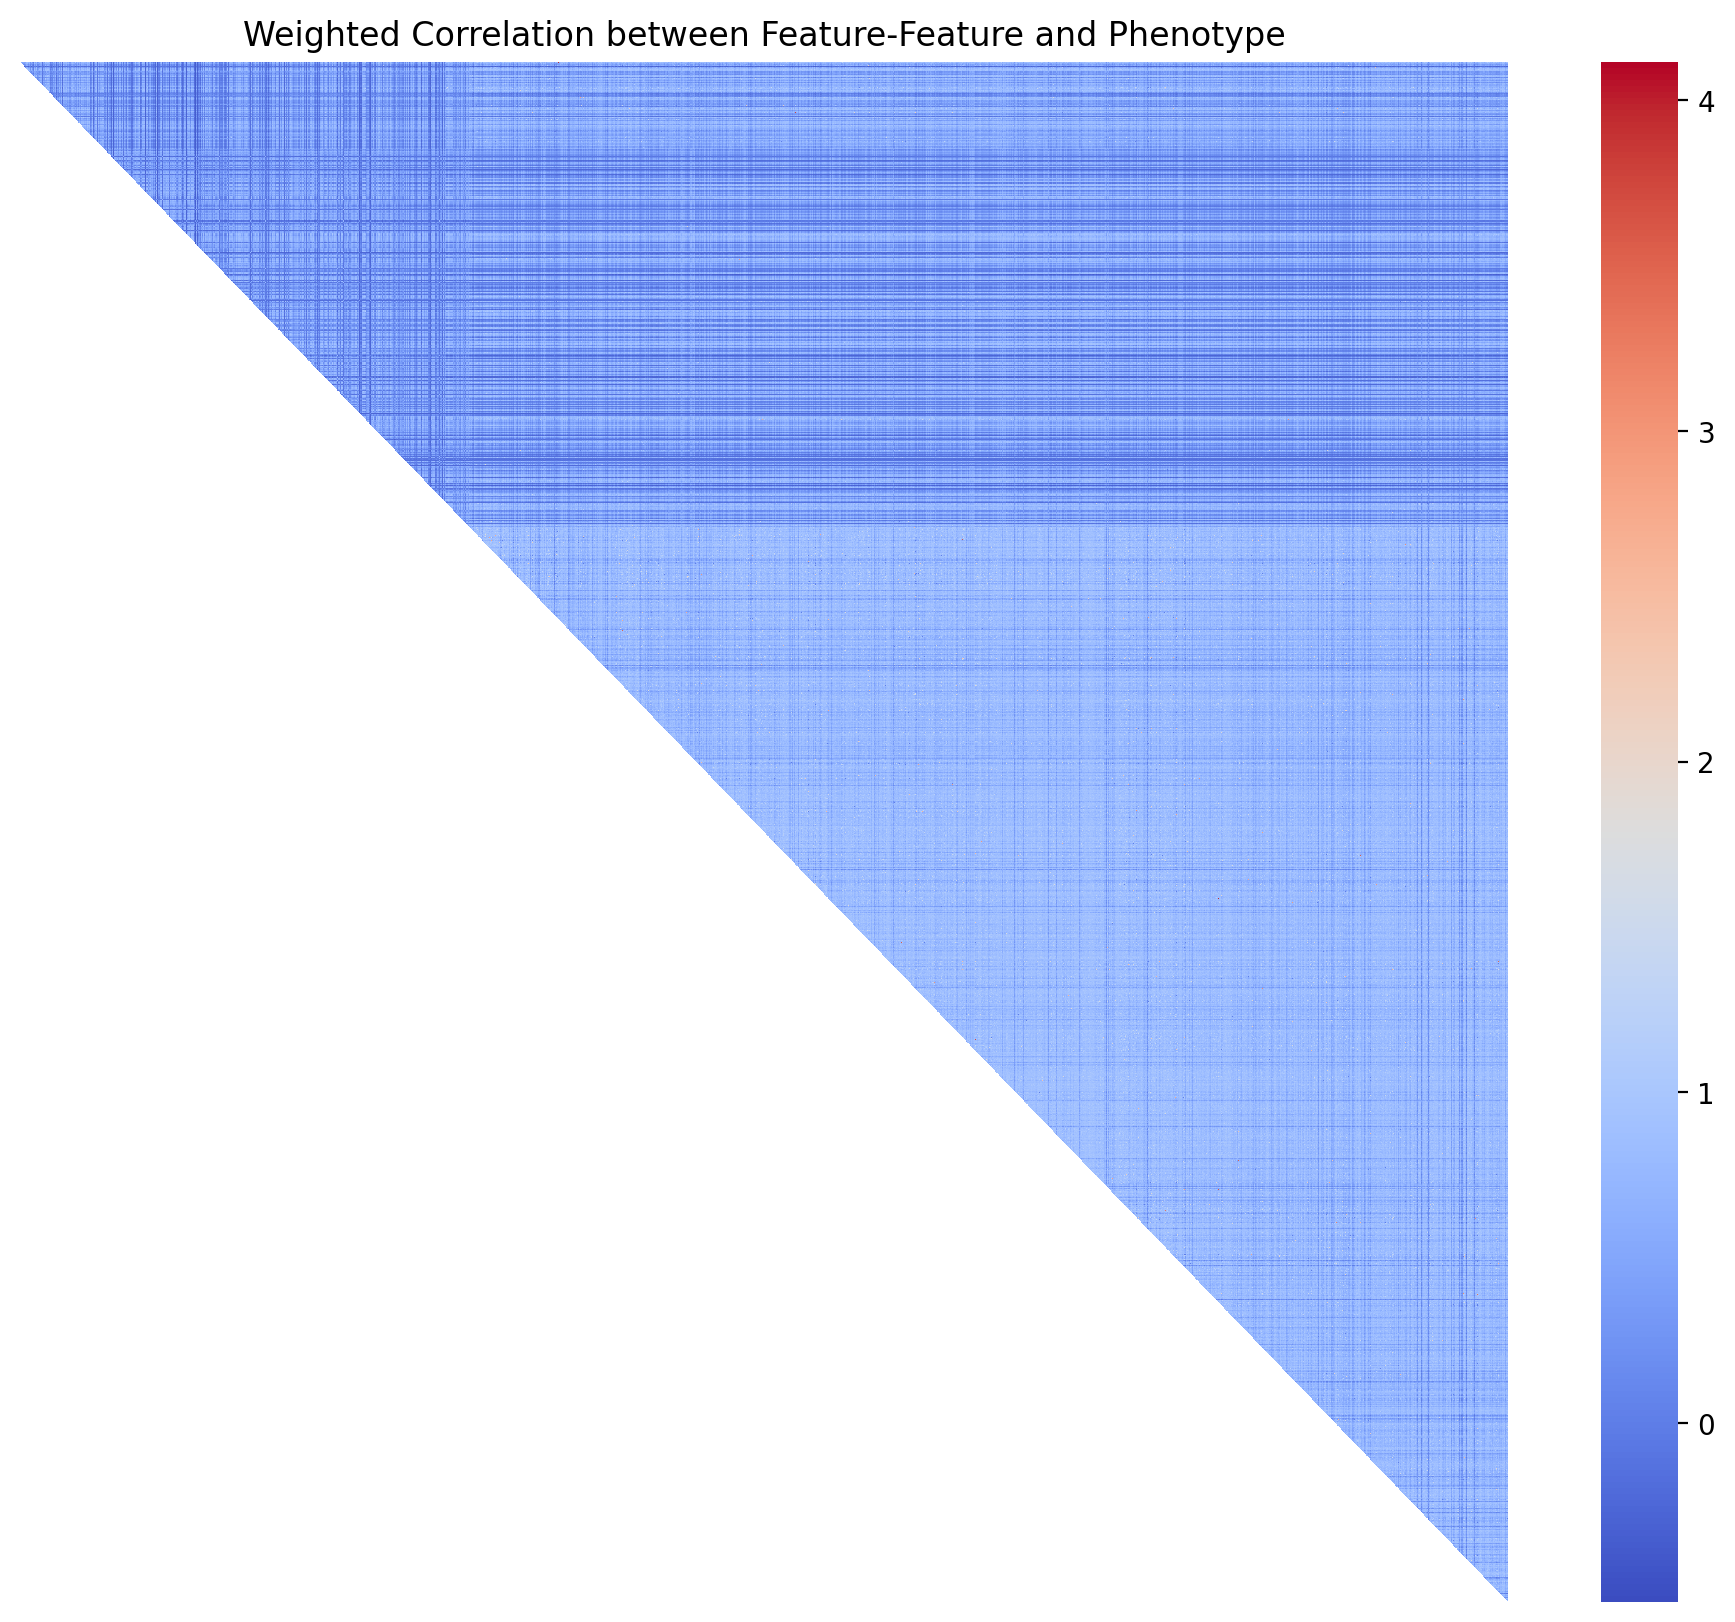

In [34]:
# Try clearing the previous plot if it exists
try:
    plt.clf()
except:
    pass

plt.figure(figsize=(12, 10))
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=feature_names, yticklabels=feature_names)

# Without axis labels for better readability.
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)

# Clustermap for better visualization of clusters.
# sns.clustermap(featfeat_pheno, cmap='coolwarm')  # , xticklabels=False, yticklabels=False)

# Clustermap with dendrogram, and upper triangle masked, without axis labels.
mask = np.tril(np.ones_like(featfeat_pheno_weighted, dtype=bool))
# sns.clustermap(featfeat_pheno, cmap='coolwarm', mask=mask, xticklabels=False, yticklabels=False)  # , dendrogram_ratio=(.1, .2))  # Adjust dendrogram size if needed. Uncomment to use.
# Failed due to the size of the matrix.

sns.heatmap(featfeat_pheno_weighted, mask=mask, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Weighted Correlation between Feature-Feature and Phenotype')
plt.show()